In [1]:
import scipy.io
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl

import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'Arial',
    'font.size': 7,
    'lines.linewidth': 0.75,
    'axes.linewidth': 0.5,
    'xtick.major.width': 0.5,
    'ytick.major.width': 0.5,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'mathtext.fontset': 'cm',
})

group_colors = {
    "CO": '#D81B60',
    "RE": '#1E88E5',
    "ST": '#FFC107',
}

In [2]:
allParams = scipy.io.loadmat('allParams.mat')['allParams'][0]

# peak magnitude (Nm), peak time (% stride), rise time (% stride), fall time (% stride)
allParams = [allParams[i][1] for i in range(15)]

# Normalize to roughly [0,1] range
# [0-1], [40-60], [20-40], [0-10]
for i in range(15):
    allParams[i][:,1] = (allParams[i][:,1] - 40) / 20
    allParams[i][:,2] = (allParams[i][:,2] - 20) / 20
    allParams[i][:,3] = allParams[i][:,3] / 10

In [3]:
def fit_single_exp(xs, ys, x_len):
    """
    Fit y = A + B * exp(-k t). Tries SciPy; falls back to NumPy-only approach.
    """
    A0 = np.min(ys)
    B0 = np.max(ys) - A0
    k0 = 0.05

    def _single_exp(x, a, b, k):
        return a + b * np.exp(-k * x)

    try:
        from scipy.optimize import curve_fit
        popt, _ = curve_fit(
            _single_exp, xs, ys,
            p0=(A0, B0, k0),
            maxfev=20000,
        )
        A, B, k = map(float, popt)
        return [A, B, k]
    except Exception:
        # NumPy fallback: scan A, linearize ln(ys - A) = ln B - k t
        A_candidates = np.linspace(np.percentile(ys, 20), np.percentile(ys, 80), 60)
        best = None
        for A in A_candidates:
            y_shift = ys - A
            mask = y_shift > 1e-8
            if mask.sum() < 5:
                continue
            t_sel = xs[mask]
            ln_sel = np.log(y_shift[mask])
            slope, intercept = np.polyfit(t_sel, ln_sel, 1)  # ln = intercept + slope * t
            B = float(np.exp(intercept))
            k = float(-slope)
            sse = float(np.sum((ys - _single_exp(xs, A, B, k)) ** 2))
            if (best is None) or (sse < best[0]):
                best = (sse, float(A), float(B), float(k))

        if best is None:
            # Degenerate fallback: flat line
            return float(np.mean(ys)), 0.0, 0.0

        _, A, B, k = best
        return [A, B, k]

def _exp_model(x, params):
    A, B, k = params
    return A + B * np.exp(-k * x)

In [4]:
def create_split_plot_xy():
    fig, axes = plt.subplots(2, 2, sharex='col', sharey='row',
                                gridspec_kw={'height_ratios': [30, 1], 'width_ratios': [1, 30]}, 
                                figsize=[2.7,2.7], dpi=120)
    # ax1 is top-left, ax2 is top-right, ax3 is bottom-left, ax4 is bottom-right
    (ax1, ax2), (ax3, ax4) = axes
    fig.subplots_adjust(hspace=0.05, wspace=0.05) # Space between axes

    # y axis
    # ax1.set_ylim(1.5,7)
    ax3.set_ylim(0,0.001)
    # x axis
    ax3.set_xlim(0,0.001)
    # ax4.set_xlim(1.5,8)

    # ax3 ticks
    ax3.set_xticks([0])
    ax3.set_yticks([0])

    # Hide spines/ticks
    ax1.spines.bottom.set_visible(False)
    ax1.spines.right.set_visible(False)
    ax2.spines.bottom.set_visible(False)
    ax2.spines.left.set_visible(False)
    ax3.spines.top.set_visible(False)
    ax3.spines.right.set_visible(False)
    ax4.spines.top.set_visible(False)
    ax4.spines.left.set_visible(False)

    ax1.tick_params(bottom=False, labelbottom=False, right=False)
    ax2.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False, right=False)
    ax3.tick_params(top=False, right=False)
    ax4.tick_params(top=False, left=False, labelleft=False, right=False)

    d = 1  # slope of slanted line
    kwargs = dict(marker=[(-1, -d), (1, d)], markersize=5,
                linestyle="none", color='k', mec='k', mew=0.5, clip_on=False)

    # y-axis break (left spine)
    ax1.plot([0], [0], transform=ax1.transAxes, **kwargs)
    ax3.plot([0], [1], transform=ax3.transAxes, **kwargs)

    # x-axis break (bottom spine)
    ax3.plot([1], [0], transform=ax3.transAxes, **kwargs)
    ax4.plot([0], [0], transform=ax4.transAxes, **kwargs)

    return fig, (ax1, ax2, ax3, ax4)

In [5]:
def fit_exp_group(indices):
    xs_fit = np.concatenate([met_time[i] for i in indices])
    ys_fit = np.concatenate([met_rate[i] for i in indices])

    params = fit_single_exp(xs_fit, ys_fit, x_len=len(xs_fit))
    return params

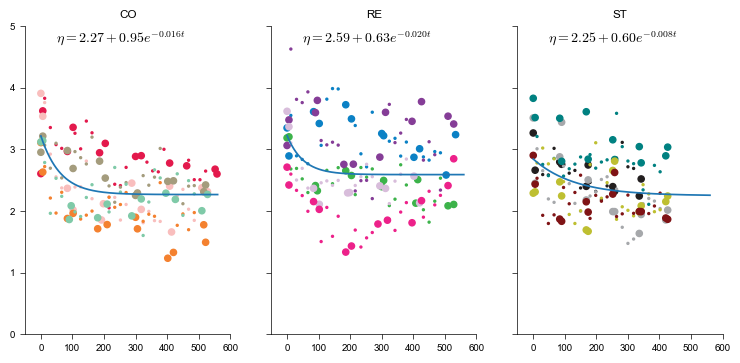

In [6]:
# load pkl data
with open('metabolic_data.pkl', 'rb') as f:
    met_rate, met_time, met_colors, met_trialtype = pkl.load(f)

fig, ax = plt.subplots(1, 3, figsize=(9,4), sharex=True, sharey=True)
ax[0].set_ylim(0,5)
ax[0].set_xlim(-50, 600)
for g in range(3):
    indices = np.arange(g*5, (g+1)*5)
    for i in indices:
        size = [20 if trialtype == '6 minute' else 2 for trialtype in met_trialtype[i]]
        ax[g].scatter(met_time[i], met_rate[i], label=f'P{i+1}', color=met_colors[i], s=size)
    params = fit_exp_group(indices=indices)
    eq_text = rf"$\eta = {params[0]:.2f} + {params[1]:.2f}e^{{-{params[2]:.3f}t}}$"
    ax[g].text(0.15, 0.95, eq_text, transform=ax[g].transAxes, fontsize=10)
    t_fit = np.linspace(0, 560, 400)
    ax[g].plot(t_fit, _exp_model(t_fit, params), linewidth=1.25)
    ax[g].set_title(["CO", "RE", "ST"][g])

In [7]:
# Each of these metric functions takes in (N,4) data from a single participant and returns a single value.

reference_params = np.array([0.54548111, 0.63676016, 0.30710462, 0.73394845]) # normalized

# Variance of parameters over 5 training days
def section_variance(params_matrix):
    k = params_matrix.shape[0] // 5
    c = 0
    vars = []
    for _ in range(5):
        vars.append(np.var(params_matrix[c:c+k,:], axis=0, ddof=1))
        c += k
    return np.mean(vars)

def individual_close(params_matrix, tol=0.1):
    values = []
    for i in range(params_matrix.shape[0]):
        score = 0
        for j in range(4):
            if np.abs(params_matrix[i,j] - reference_params[j]) < tol:
                score += 1
            elif np.abs(params_matrix[i,j] - reference_params[j]) < tol:
                score += 1
        values.append(score)
    return np.mean(values)

In [8]:
# Pre-compute metrics for all 15 participants (one-time cost)
all_metrics = {
    'section_variance': np.array([section_variance(allParams[i]) for i in range(15)]),
    'individual_close': np.array([individual_close(allParams[i], tol=0.1) for i in range(15)]),
}

all_values = [[] for _ in range(3)]

np.random.seed(42)
for group in range(3):
    if group == 0:
        indices = [0,1,2,3,4]
    elif group == 1:
        indices = [5,6,7,8,9]
    else:
        indices = [10,11,12,13,14]

    while len(all_values[group]) < 200:
        indices_bootstrap = np.random.choice(indices, size=10, replace=True)
        params = fit_exp_group(indices=indices_bootstrap)

        if params[0] < 0.05:
            continue
        if np.log(20.0)/params[2] > 1000:
            continue

        all_values[group].append([params[0], np.log(20.0)/params[2],
                                  np.mean(all_metrics['section_variance'][indices_bootstrap]),
                                  np.mean(all_metrics['individual_close'][indices_bootstrap]),
                                  ])
all_values = np.array(all_values)

import pandas as pd
import statsmodels.formula.api as smf
records = []
group_labels = ["CO", "RE", "ST"]
for j in range(3):
    for i in range(all_values.shape[1]):
        records.append({
            "Group": group_labels[j],
            "A": all_values[j,i,0],
            "tt5": all_values[j,i,1],
            "SectionVariance": all_values[j,i,2],
            "Close": all_values[j,i,3],
        })
df_boot = pd.DataFrame(records)

A = 2.3698 + -0.4145 * SectionVariance + 0.3485 * Close


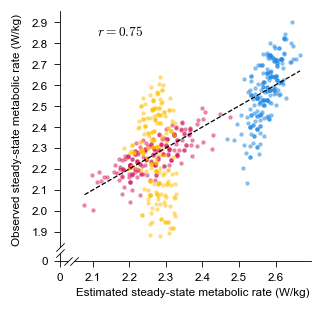

tt5 = 219.4825 + -304.2020 * SectionVariance + 985.5521 * Close


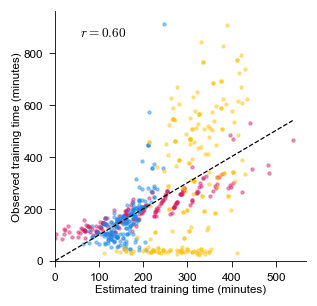

In [9]:
cols_to_norm = ["SectionVariance", "Close"]

df_clean = df_boot.dropna().copy()
df_std = df_clean.copy()

for col in cols_to_norm:
    if df_std[col].std() > 0:
        df_std[col] = (df_std[col] - df_std[col].mean()) / df_std[col].std()

for target_var in ["A", "tt5"]:
    # Linear mixed model with random intercept per group
    formula = f"{target_var} ~ " + " + ".join(cols_to_norm)

    model_all = smf.mixedlm(formula, data=df_std, groups=df_std["Group"]).fit()

    predictions = model_all.fittedvalues
    actual = df_std[target_var]

    print(f"{target_var} = {model_all.params['Intercept']:.4f} + " + " + ".join([f"{model_all.params[col]:.4f} * {col}" for col in cols_to_norm]))

    if target_var == "A":
        fig, axs = create_split_plot_xy()
        ax = axs[1]
        ax.set_xlabel("Estimated steady-state metabolic rate (W/kg)", labelpad=24)
        ax.set_ylabel("Observed steady-state metabolic rate (W/kg)", labelpad=31)
        ax.set_xticks(np.arange(2.1, 2.7, 0.1))
        ax.set_yticks(np.arange(1.8, 3.01, 0.1))
    elif target_var == "tt5":
        fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=120)
        ax.set_xlabel("Estimated training time (minutes)", labelpad=1)
        ax.set_ylabel("Observed training time (minutes)", labelpad=1)

    for group in df_std["Group"].unique():
        idx = df_std["Group"] == group
        ax.scatter(predictions[idx], actual[idx], alpha=0.4, color=group_colors.get(group, 'purple'), label=group, s=3)

    m, b = np.polyfit(predictions, actual, 1)
    x_range = np.linspace(predictions.min(), predictions.max(), 100)
    ax.plot(x_range, m*x_range + b, color="black", linestyle="--", label="Fit")
    corr = np.corrcoef(predictions, actual)[0,1]
    ax.text(0.1, 0.9, rf"$r = {corr:.2f}$", transform=ax.transAxes, fontsize=8)

    if target_var == "tt5":
        ax.set_xlim(left=0)
        ax.set_ylim(bottom=0)

    save_path = f"./plot/corr_{target_var}.png"
    fig.patch.set_visible(False)
    fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
    fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
    fig.patch.set_visible(True)
    plt.show()

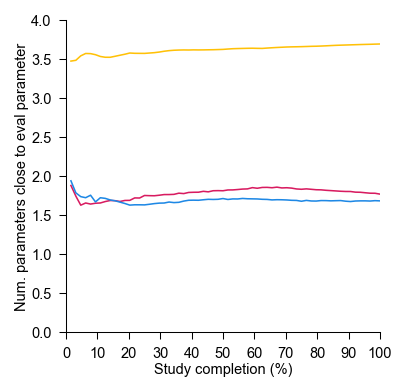

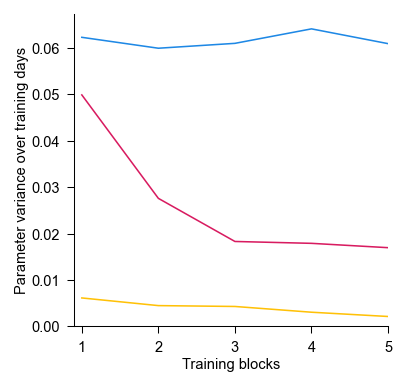

In [10]:
# Plot metrics over training trials
labels = ["CO", "RE", "ST"]

fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=150)
k = 64
for group in range(3): # for each group
    values_all = []
    for i in range(group*5, (group+1)*5): # for each participant in the group
        values = []
        # calculate metrics for training trials up to N/k, 2N/k, ..., N trials
        for j in range(k):
            slice = allParams[i][:allParams[i].shape[0]*(j+1)//k,:].copy()
            values.append(individual_close(slice))
        values_all.append(values)
    plt.plot(np.arange(k)+1, np.mean(values_all, axis=0), label=labels[group], color=group_colors[labels[group]])
plt.xlabel("Study completion (%)", labelpad=1)
plt.xticks([i*(k/10) for i in range(11)], [str(i*10) for i in range(11)])
plt.yticks([0,0.5,1,1.5,2,2.5,3,3.5,4])
plt.ylabel("Num. parameters close to eval parameter", labelpad=1)
plt.xlim(left=0, right=k)
plt.ylim(bottom=0)
save_path = f"./plot/metric_specificity.png"
fig.patch.set_visible(False)
fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
fig.patch.set_visible(True)
plt.show()

fig, ax = plt.subplots(figsize=(2.7, 2.7), dpi=150)
k = 5
for group in range(3): # for each group
    values_all = []
    for i in range(group*5, (group+1)*5): # for each participant in the group
        values = []
        k2 = allParams[i].shape[0] // k
        c = 0
        for _ in range(k):
            values.append(np.mean(np.var(allParams[i][c:c+k2,:], axis=0, ddof=1)))
            c += k2
        values_all.append(values)
    plt.plot(np.arange(k)+1, np.mean(values_all, axis=0), label=labels[group], color=group_colors[labels[group]])
plt.xlabel("Training blocks", labelpad=1)
plt.xticks([1,2,3,4,5])
plt.ylabel("Parameter variance over training days", labelpad=1)
plt.xlim(left=0.9, right=k)
plt.ylim(bottom=0)
save_path = f"./plot/metric_variance.png"
fig.patch.set_visible(False)
fig.savefig(save_path, dpi=300, bbox_inches="tight", transparent=True)
fig.savefig(save_path.replace(".png", ".svg"), dpi=300, bbox_inches="tight", transparent=True)
fig.patch.set_visible(True)
plt.show()